# PRÁCTICA MACHINE LEARNING

## Graph Classification with Graph Neural Networks. Dataset: PROTEINS

Profesor: Francisco Escolano

Alumno: Nicolás Vives Vicente

La tarea más común para la clasificación de grafos es la **predicción de propiedades moleculares**, en la que las moléculas se representan como grafos, y la tarea puede consistir en inferir si una molécula inhibe la replicación del virus del VIH o no.

La Universidad Técnica de Dortmund ha recopilado una amplia gama de diferentes conjuntos de datos de clasificación de grafos, conocidos como [**TUDatasets**](https://chrsmrrs.github.io/datasets/), los cuales también son accesibles a través de [`torch_geometric.datasets.TUDataset`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.TUDataset) en PyTorch Geometric.

En este notebook se estudia el **conjunto de datos PROTEINS**:

## Librerías necesarias:

In [1]:
# Librerías Estándar de Python
import os
import csv
import random
from collections import Counter

# Análisis de Datos, Grafos y Visualización
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# PyTorch
import torch
import torch.nn.functional as F
from torch.nn import Linear

# PyTorch Geometric (Utilidades)
import torch_geometric.data
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx, to_dense_batch, to_dense_adj

# PyTorch Geometric (Capas GNN y Pooling)
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool  # Global Mean Pooling
from torch_geometric.nn import global_add_pool   # Global Add Pooling
from torch_geometric.nn import global_max_pool   # Global Max Pooling

# Modelo Net
from torch_geometric.nn import dense_mincut_pool, DenseGraphConv

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Inspección del dataset:

In [3]:
dataset = TUDataset(root='data/TUDataset', name='PROTEINS')

print()
print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Extraemos las etiquetas (y) de cada grafo y las contamos
labels = [data.y.item() for data in dataset]
class_counts = Counter(labels)

print('====================')
print('Samples per class:')
for cls, count in sorted(class_counts.items()):
    print(f' - Class {cls}: {count}')
print('====================')

num_nodes_list = [data.num_nodes for data in dataset]

mean_nodes = np.mean(num_nodes_list)
min_nodes = np.min(num_nodes_list)
max_nodes = np.max(num_nodes_list)

print('Node statistics per molecule:')
print(f' - Mean nodes: {mean_nodes:.2f}')
print(f' - Min nodes: {min_nodes}')
print(f' - Max nodes: {max_nodes}')
print('====================')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('=============================================================')

# Gather some statistics about the first graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Dataset: PROTEINS(1113):
Number of graphs: 1113
Number of features: 3
Number of classes: 2
Samples per class:
 - Class 0: 663
 - Class 1: 450
Node statistics per molecule:
 - Mean nodes: 39.06
 - Min nodes: 4
 - Max nodes: 620

Data(edge_index=[2, 162], x=[42, 3], y=[1])
Number of nodes: 42
Number of edges: 162
Average node degree: 3.86
Has isolated nodes: False
Has self-loops: False
Is undirected: True


Este conjunto de datos proporciona **1113 grafos diferentes**, y la tarea consiste en clasificar cada grafo en **una de dos clases**.

Al inspeccionar el primer objeto de grafo del conjunto de datos, podemos ver que cuenta con **42 nodos (con vectores de características de 3 dimensiones)** y **162 aristas** (lo que resulta en un grado promedio de nodo de 3.86). También cuenta con exactamente **una etiqueta de grafo** (`y=[1]`).

La media de nodos por molécula es de 39.06, la molécula más pequeña tiene 4 nodos y la más grande 620.


Como tenemos dos clases, veamos un ejemplo de molécula perteneciente a cada una de ellas.

tensor([0])
tensor([1])


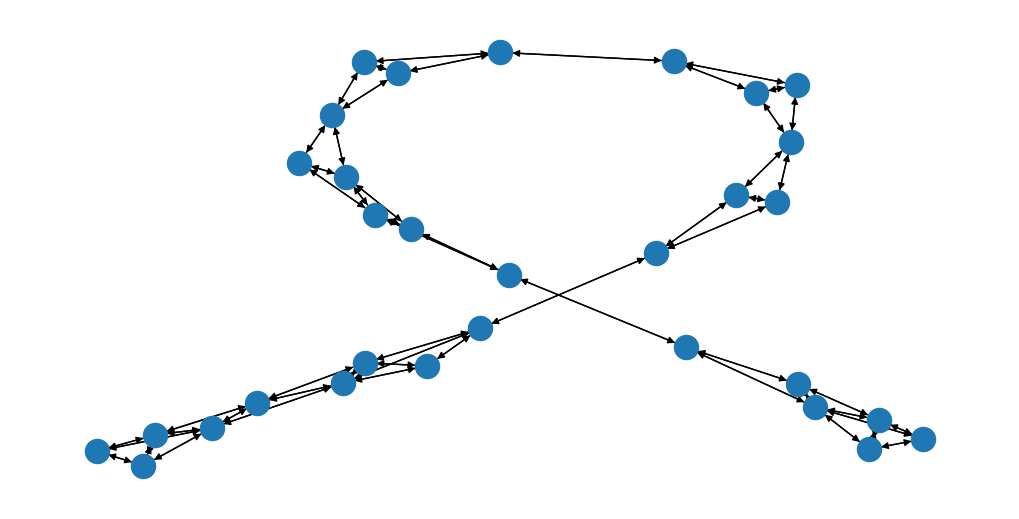

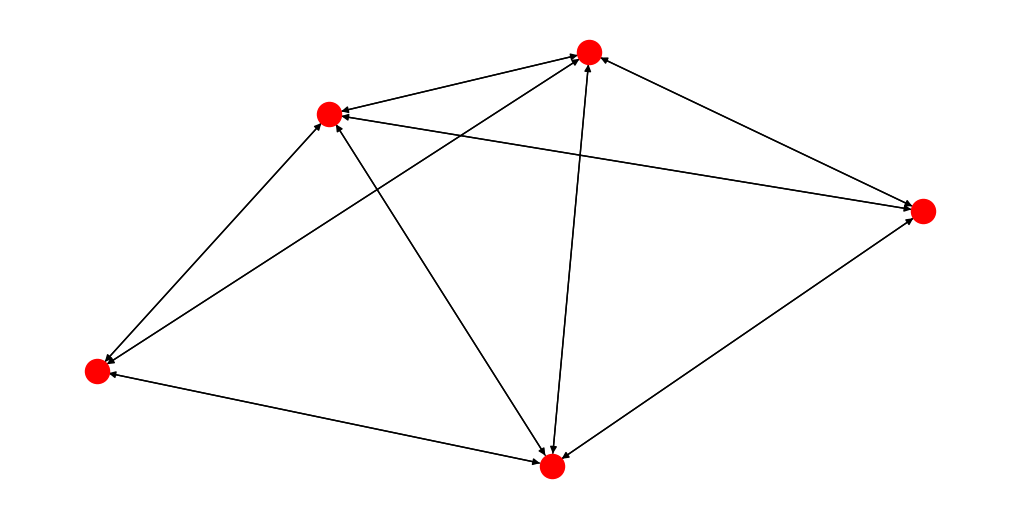

In [8]:
data = random.choice([t for t in dataset if t.y==0])
g = to_networkx(data)
plt.figure(figsize=(10, 5))
nx.draw(g)
print(data.y)

data = random.choice([t for t in dataset if t.y==1])
g = to_networkx(data)
plt.figure(figsize=(10, 5))
nx.draw(g,node_color='r')
print(data.y)


Antes de comenzar con el entrenamiento y evaluación de los modelos conviene mencionar que se han detectado algunos problemas en el código proporcionado para la práctica y se han solucionado de las siguientes formas:

- Cálculo Aislado del Espectro Laplaciano (Graph-by-Graph):

    - Problema: Calcular el Laplaciano sobre el batch completo genera un grafo enorme, con tantas componentes desconectadas como moléculas haya en el lote. Matemáticamente, esto produce un autovalor igual a cero por cada componente. Al seleccionar los $k$ primeros, estos ceros acaparan la selección, entregando a la red autovectores vacíos que hacen inútil la geometría espacial y disparan el coste computacional al operar sobre una matriz gigante.

    - Solución implementada: Se ha aplicado una estrategia de "divide y vencerás", modificando la función para que desempaquete el lote y calcule el Laplaciano molécula por molécula de forma estrictamente individual. Esto garantiza un único autovalor cero por grafo, permitiendo que el resto de los $k$ autovectores extraigan correctamente las auténticas frecuencias estructurales y formas tridimensionales, reduciendo además la complejidad computacional.

- Corrección del Bucle de Validación (DataLoaders y Reproducibilidad):

    - Problema: La evaluación de modelos (incluyendo la red base Net) estaba consumiendo DataLoaders instanciados globalmente al inicio del notebook. Esto provocaba que, aunque los modelos variaran sus pesos iniciales y por tanto sí daban resultados distintos, no se estaba respetando la semilla de reproducibilidad para la partición de datos en las distintas iteraciones.

    - Solución implementada: Se ha reestructurado el bucle principal de evaluación. Ahora, la división del dataset y la generación de los train_loader y test_loader se ejecutan internamente en cada iteración, garantizando que los datos de entrenamiento y prueba cambien respetando la partición de los datos según la semilla activa.

Funciones heredadas con las modificaciones aplicadas:

In [4]:
def compute_laplacian_eigenvectors_pytorch(data, k):
    # 1. Convert PyTorch Geometric graph to NetworkX graph
    g = to_networkx(data, to_undirected=True)

    # 2. Compute the normalized Laplacian matrix using NetworkX
    # networkx.normalized_laplacian_matrix returns a sparse matrix
    # Then we make it dense and compatible with numpy
    L = nx.normalized_laplacian_matrix(g).todense()

    # 3. Finding eigen values and eigen vectors
    e, evecs = np.linalg.eig(L)
    #e.shape, evecs.shape

    # 4. Sort eigenvectors
    # Sort them (both e's and evecs's) ascending
    idx =e.argsort()
    e = e[idx]
    evecs = evecs[:,idx]

    # 3. Convert the sparse Laplacian matrix to a dense PyTorch tensor
    # Convert to dense numpy array first, then to torch tensor
    evecs_torch = torch.tensor(np.real(evecs[:,:k]), dtype=torch.float32)

    return evecs_torch

# Train and test functions. Use k=0 when no spectral info
def train(model, train_loader, optimizer, k):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for data in train_loader:  # Iterate in batches over the training dataset.
        optimizer.zero_grad()
        # Ensure all data components are on the correct device
        data.x = data.x.to(device)
        data.edge_index = data.edge_index.to(device)
        data.y = data.y.to(device)
        data.batch = data.batch.to(device)

        # MODIFICACIÓN
        if k > 0:
            evecs_list = []
            # Desempaquetamos el batch en grafos individuales
            for single_graph in data.to_data_list():
                # Calculamos el Laplaciano molécula por molécula
                evecs_single = compute_laplacian_eigenvectors_pytorch(single_graph, k=k)
                num_evecs = evecs_single.size(1)
                if num_evecs < k:
                    columnas_faltantes = k - num_evecs
                    # Rellenamos con ceros las columnas que faltan
                    evecs_single = F.pad(evecs_single, (0, columnas_faltantes, 0, 0), "constant", 0.0)
                
                evecs_list.append(evecs_single)
            
            # Volvemos a unir los resultados en un solo tensor y lo pasamos a la GPU
            evecs_torch = torch.cat(evecs_list, dim=0).to(device)
            # Concatenamos con las características originales
            data.x = torch.cat([data.x, evecs_torch], dim=1)
        # FIN MODIFICACIÓN

        # Pass data components to the model
        out = model(data.x, data.edge_index, data.batch)

        loss = criterion(out, data.y)  # Compute the loss.
        loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters based on gradients.

        total_loss += loss.item() * data.y.size(0)
        pred = out.argmax(dim=1)
        total_correct += (pred == data.y).sum().item()
        total_samples += data.y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def test(model, loader, k):
    model.eval()
    total_correct = 0
    total_samples = 0
    total_loss = 0

    with torch.no_grad():
        for data in loader:  # Iterate in batches over the training/test dataset.
            # Ensure all data components are on the correct device
            data.x = data.x.to(device)
            data.edge_index = data.edge_index.to(device)
            data.y = data.y.to(device)
            data.batch = data.batch.to(device)

        # MODIFICACIÓN
            if k > 0:
                evecs_list = []
                for single_graph in data.to_data_list():
                    evecs_single = compute_laplacian_eigenvectors_pytorch(single_graph, k=k)
                    num_evecs = evecs_single.size(1)
                    if num_evecs < k:
                        columnas_faltantes = k - num_evecs
                        # Rellenamos con ceros las columnas que faltan
                        evecs_single = F.pad(evecs_single, (0, columnas_faltantes, 0, 0), "constant", 0.0)
                    
                    evecs_list.append(evecs_single)
                
                evecs_torch = torch.cat(evecs_list, dim=0).to(device)
                data.x = torch.cat([data.x, evecs_torch], dim=1)
        # FIN MODIFICACIÓN

            out = model(data.x, data.edge_index, data.batch)

            loss = criterion(out, data.y) # Compute the loss.
            total_loss += loss.item() * data.y.size(0)

            pred = out.argmax(dim=1)  # Use the class with highest probability.
            total_correct += int((pred == data.y).sum())  # Check against ground-truth labels.
            total_samples += data.y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def split(dataset, seed):
  torch.manual_seed(seed)
  dataset = dataset.shuffle()

  # Get 25% approx per test
  split_idx = int(len(dataset) * 0.75)
  print("split idx", split_idx)

  train_dataset = dataset[:split_idx]
  test_dataset = dataset[split_idx:]

  #print(f'Number of training graphs: {len(train_dataset)}')
  #print(f'Number of test graphs: {len(test_dataset)}')
  return train_dataset, test_dataset

## Experimento 1: Evaluación de Arquitecturas Base

Comenzamos el análisis del dataset **PROTEINS** estableciendo las líneas base. Al igual que en los casos anteriores, el objetivo es evaluar el impacto de la información geométrica en la clasificación de las moléculas, abordando en este conjunto un problema binario (enzima vs. no enzima).

En esta fase inicial, se utilizará la configuración predeterminada del *notebook* para comprobar el comportamiento base de las redes al enfrentarse a este conjunto de datos:

| Hiperparámetro | Valor |
| :--- | :--- |
| Canales Ocultos (*Hidden Channels*) | 64 |
| Número de Capas Convolucionales | 3 |
| Resolución Espectral ($k$) | 4 |
| Tipo de Agregación (*Pooling*) | Global Mean Pool |

Las redes se han adaptado específicamente a la dimensionalidad de este nuevo problema de clasificación binaria:

* **GCN (Línea base):** Su primera capa recibe **3 dimensiones** (las características bioquímicas de los nodos). Tras 3 capas de 64 canales, finaliza en una capa lineal que emite una predicción sobre **2 clases posibles**, ignorando completamente la topología global del grafo.
* **GCNEig (Fusión temprana):** Añade la codificación espectral desde el inicio. Su entrada se amplía a **7 dimensiones** (3 características bioquímicas + 4 espaciales). Esto permite a la red procesar simultáneamente los atributos del nodo y su posición global en la estructura desde el primer salto de mensaje.
* **GCNEigDecoupled (Fusión tardía):** Emplea vías de procesamiento paralelas. Analiza las características iniciales en la rama convolucional (entrada de 3 dimensiones) y la geometría espacial en una proyección lineal independiente (proyectando los 4 autovectores a 32 canales). Ambas señales se concatenan en la profundidad de la red antes de emitir la clasificación binaria en la capa final.

In [10]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(3, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(3, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [11]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Mean Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_PROTEINS.csv")
        with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 834
Epoch: 001, Loss: 0.68441, Train Acc: 0.57914
Epoch: 002, Loss: 0.67107, Train Acc: 0.63309
Epoch: 003, Loss: 0.66483, Train Acc: 0.62110
Epoch: 004, Loss: 0.68170, Train Acc: 0.56115
Epoch: 005, Loss: 0.65877, Train Acc: 0.60552
Epoch: 006, Loss: 0.65874, Train Acc: 0.64988
Epoch: 007, Loss: 0.63439, Train Acc: 0.68945
Epoch: 008, Loss: 0.63705, Train Acc: 0.67386
Epoch: 009, Loss: 0.63007, Train Acc: 0.65947
Epoch: 010, Loss: 0.62102, Train Acc: 0.69065
Epoch: 011, Loss: 0.61473, Train Acc: 0.70024
Epoch: 012, Loss: 0.62291, Train Acc: 0.68945
Epoch: 013, Loss: 0.61586, Train Acc: 0.68585
Epoch: 014, Loss: 0.64193, Train Acc: 0.66427
Epoch: 015, Loss: 0.64084, Train Acc: 0.66547
Epoch: 016, Loss: 0.64143, Train Acc: 0.66906
Epoch: 017, Loss: 0.62694, Train Acc: 0.67626
Epoch: 018, Loss: 0.62424, Train Acc: 0.69305
Epoch: 019, Loss: 0.63081, Train Acc: 0.66787
Epoch: 020, Loss: 0.61639, Train Acc: 0.68585
Epo

Tras evaluar la configuración predeterminada, se obtuvieron las siguientes métricas de rendimiento:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Mean | 0 | $68.66 \pm 1.94$ | $68.42 \pm 2.74$ |
| **GCNEig** | 64 | 3 | Mean | 4 | $75.54 \pm 0.96$ | $\mathbf{72.54 \pm 2.64}$ |
| **GCNEigDecoupled** | 64 | 3 | Mean | 4 | $74.27 \pm 1.35$ | $71.97 \pm 2.26$ |

* Se observa una mejora significativa en los porcentajes de precisión en comparación con ENZYMES. Al tratarse de una clasificación binaria (enzima o no enzima), el problema matemático se simplifica considerablemente, partiendo de un umbral de acierto aleatorio del **~50%**.
* A diferencia de lo ocurrido inicialmente en ENZYMES, añadir autovectores del Laplaciano resulta útil desde el primer momento. Las variantes espectrales `GCNEig` (**72.54%**) y `GCNEigDecoupled` (**71.97%**) superan con claridad al modelo base `GCN` (68.42%), logrando un incremento de aproximadamente 4 puntos porcentuales en validación.
* Los modelos con información espectral no solo mejoran la precisión absoluta, sino que mantienen desviaciones estándar bajas (en torno a **±2.5**). Esto indica una gran robustez del modelo frente a diferentes inicializaciones.

A pesar de estos buenos resultados iniciales, no debemos olvidar que estamos trabajando nuevamente con macromoléculas. Existe el riesgo de que el uso del promedio global (`Mean Pool`) esté diluyendo señales locales críticas de la estructura de las proteínas. 

Esto justifica avanzar al **Experimento 2**, donde exploraremos otras funciones de agregación para comprobar si, al aislar estas características clave, somos capaces de elevar aún más el rendimiento predictivo de las redes.

## Experimento 2: Impacto de `Global Max Pool`

En este experimento se modifica la capa de agregación (*readout layer*) basándonos en la hipótesis de que el promedio (`Mean Pool`) podría estar ocultando información estructural vital en las proteínas más complejas.

La decisión de cambiar este criterio se basa en la extrema variabilidad topológica del dataset:

Los grafos en PROTEINS oscilan drásticamente desde pequeñas estructuras de 4 nodos hasta enormes macromoléculas de 620 nodos. Aplicar una suma (`Add Pool`) resulta inviable, ya que la magnitud del vector latente dependería casi exclusivamente del tamaño de la proteína, sesgando por completo a la red. Se implementa `Global Max Pool` debido a su invarianza al tamaño de entrada. Esta operación matemática actúa como un detector de características, permitiendo a la red aislar y capturar la señal de una región activa específica, sin importar la cantidad de nodos que conformen el resto de la estructura.

In [14]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(3, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(3, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [15]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_PROTEINS.csv")
        with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 834
Epoch: 001, Loss: 0.66079, Train Acc: 0.59712
Epoch: 002, Loss: 0.58333, Train Acc: 0.69784
Epoch: 003, Loss: 0.59368, Train Acc: 0.72062
Epoch: 004, Loss: 0.59978, Train Acc: 0.69305
Epoch: 005, Loss: 0.58916, Train Acc: 0.71103
Epoch: 006, Loss: 0.58893, Train Acc: 0.72422
Epoch: 007, Loss: 0.59072, Train Acc: 0.70743
Epoch: 008, Loss: 0.58257, Train Acc: 0.72182
Epoch: 009, Loss: 0.56220, Train Acc: 0.73261
Epoch: 010, Loss: 0.56642, Train Acc: 0.73141
Epoch: 011, Loss: 0.56874, Train Acc: 0.73022
Epoch: 012, Loss: 0.56918, Train Acc: 0.73741
Epoch: 013, Loss: 0.56213, Train Acc: 0.73501
Epoch: 014, Loss: 0.56833, Train Acc: 0.74460
Epoch: 015, Loss: 0.58634, Train Acc: 0.71223
Epoch: 016, Loss: 0.57099, Train Acc: 0.70983
Epoch: 017, Loss: 0.56306, Train Acc: 0.74221
Epoch: 018, Loss: 0.55727, Train Acc: 0.74221
Epoch: 019, Loss: 0.56967, Train Acc: 0.71942
Epoch: 020, Loss: 0.56377, Train Acc: 0.73981
Epo

Las métricas obtenidas tras implementar la extracción de características máximas se detallan a continuación:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Max | 0 | $73.63 \pm 1.70$ | $71.47 \pm 2.30$ |
| **GCNEig** | 64 | 3 | Max | 4 | $77.69 \pm 1.10$ | $\mathbf{72.97 \pm 3.06}$ |
| **GCNEigDec.** | 64 | 3 | Max | 4 | $76.99 \pm 1.24$ | $72.22 \pm 2.87$ |

* El modelo `GCN` es el que más aprovecha este cambio en la agregación, elevando su precisión en validación desde un 68.42% (obtenido con `Mean Pool`) hasta un notable 71.47%.
* Las arquitecturas con información geométrica mantienen el liderazgo. `GCNEig` se posiciona ligeramente por encima con un **72.97%** en validación, seguido muy de cerca por `GCNEigDecoupled` (72.22%), confirmando que la geometría sigue aportando valor para clasificar estas estructuras.
* A diferencia del caótico sobreajuste observado en el dataset ENZYMES, en PROTEINS vemos un comportamiento mucho más controlado. Las precisiones de entrenamiento se mantienen entre el 73% y el 77%, lo que demuestra que la red está aprendiendo patrones generalizables sin llegar a memorizar descaradamente los datos.

A pesar de la estabilidad general, persiste una leve brecha (entre 4 y 5 puntos porcentuales) entre *Train* y *Test* en las redes espectrales, lo que señala un ligero *overfitting*. 

Dado que PROTEINS es un problema de clasificación binaria (analíticamente más sencillo que las 6 clases de ENZYMES), es posible que 64 canales ocultos impliquen un exceso de parámetros innecesarios. Sin embargo, la extrema diferencia en el tamaño de los grafos (de 4 a 620 nodos) también podría exigir una mayor estructura de red. 

Esto motiva el **Experimento 3**, donde alteraremos la capacidad de representación (*Hidden Channels*):
1. Evaluaremos **dimensiones inferiores (32 canales)** para comprobar si el modelo necesita regularización.
2. Evaluaremos **dimensiones superiores (128 canales)** para explorar el límite de aprendizaje y capacidad de la red.

## Experimento 3: Ajuste de Canales Ocultos (*Hidden Channels*)

Para resolver la ligera brecha de sobreajuste detectada en el experimento anterior, evaluaremos el impacto de variar la dimensionalidad de las capas ocultas (*hidden channels*), probando con configuraciones de **32 y 128 canales**.

La clasificación binaria (enzima vs. no enzima) presenta una complejidad matemática menor que la clasificación multiclase vista en conjuntos anteriores. El leve sobreajuste observado al usar 64 canales plantea dos escenarios posibles ante la variabilidad extrema en el tamaño de estas macromoléculas (de 4 a 620 nodos):

* **Hipótesis 1 - Necesidad de Regularización (32 canales):** El modelo está sobre-parametrizado. Tiene demasiada libertad y la está utilizando para memorizar los datos de entrenamiento. Reducir los canales actuaría como una restricción directa, forzando a la red a retener solo los patrones más generalizables.
* **Hipótesis 2 - Necesidad de Capacidad (128 canales):** La gigantesca variación en la escala de las proteínas demanda una altísima capacidad de memoria estructural para que la red pueda comprender los grafos más grandes sin colapsar. Aumentar los parámetros le daría el espacio necesario.

Evaluar ambos extremos nos permitirá comprobar de forma empírica si el problema requiere una estricta regularización dimensional o si, por el contrario, exige una mayor capacidad de memoria para resolverse óptimamente.

In [18]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=32,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=32, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=32, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(3, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(7, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(3, 32)
  (conv2): GCNConv(32, 16)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=16, bias=True)
)


In [19]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 32
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_PROTEINS.csv")
        with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 834
Epoch: 001, Loss: 0.67777, Train Acc: 0.60072
Epoch: 002, Loss: 0.66229, Train Acc: 0.62350
Epoch: 003, Loss: 0.60507, Train Acc: 0.69424
Epoch: 004, Loss: 0.58070, Train Acc: 0.72782
Epoch: 005, Loss: 0.58403, Train Acc: 0.71343
Epoch: 006, Loss: 0.56997, Train Acc: 0.71343
Epoch: 007, Loss: 0.58177, Train Acc: 0.71942
Epoch: 008, Loss: 0.57297, Train Acc: 0.73141
Epoch: 009, Loss: 0.57368, Train Acc: 0.70743
Epoch: 010, Loss: 0.58342, Train Acc: 0.73381
Epoch: 011, Loss: 0.57143, Train Acc: 0.72542
Epoch: 012, Loss: 0.56700, Train Acc: 0.73261
Epoch: 013, Loss: 0.56843, Train Acc: 0.73501
Epoch: 014, Loss: 0.58827, Train Acc: 0.72062
Epoch: 015, Loss: 0.58507, Train Acc: 0.71583
Epoch: 016, Loss: 0.57434, Train Acc: 0.71463
Epoch: 017, Loss: 0.58002, Train Acc: 0.73381
Epoch: 018, Loss: 0.56708, Train Acc: 0.72662
Epoch: 019, Loss: 0.55553, Train Acc: 0.74101
Epoch: 020, Loss: 0.56555, Train Acc: 0.72902
Epo

In [21]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=128,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=128, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=128, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(7, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=64, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 128
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_PROTEINS.csv")
        with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 834
Epoch: 001, Loss: 0.64005, Train Acc: 0.65588
Epoch: 002, Loss: 0.58954, Train Acc: 0.72542
Epoch: 003, Loss: 0.59402, Train Acc: 0.71463
Epoch: 004, Loss: 0.57882, Train Acc: 0.73621
Epoch: 005, Loss: 0.59689, Train Acc: 0.71463
Epoch: 006, Loss: 0.56251, Train Acc: 0.73261
Epoch: 007, Loss: 0.55705, Train Acc: 0.73022
Epoch: 008, Loss: 0.58040, Train Acc: 0.70743
Epoch: 009, Loss: 0.58076, Train Acc: 0.70983
Epoch: 010, Loss: 0.56120, Train Acc: 0.71942
Epoch: 011, Loss: 0.57393, Train Acc: 0.69904
Epoch: 012, Loss: 0.57932, Train Acc: 0.72542
Epoch: 013, Loss: 0.57779, Train Acc: 0.71583
Epoch: 014, Loss: 0.56234, Train Acc: 0.72662
Epoch: 015, Loss: 0.58796, Train Acc: 0.71703
Epoch: 016, Loss: 0.57751, Train Acc: 0.72782
Epoch: 017, Loss: 0.57761, Train Acc: 0.70983
Epoch: 018, Loss: 0.58479, Train Acc: 0.72542
Epoch: 019, Loss: 0.60072, Train Acc: 0.70384
Epoch: 020, Loss: 0.56786, Train Acc: 0.71703
Epo

La evaluación comparativa entre las configuraciones de 32 y 128 canales ha proporcionado las siguientes métricas:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Configuración: 32 Canales** | | | | | | |
| **GCN** | 32 | 3 | Max | 0 | $73.26 \pm 1.46$ | $72.26 \pm 2.59$ |
| **GCNEig** | 32 | 3 | Max | 4 | $76.86 \pm 1.60$ | $72.87 \pm 3.16$ |
| **GCNEigDec.** | 32 | 3 | Max | 4 | $76.45 \pm 1.61$ | $\mathbf{73.48 \pm 2.57}$ |
| **Configuración: 128 Canales** | | | | | | |
| **GCN** | 128 | 3 | Max | 0 | $73.25 \pm 1.71$ | $72.33 \pm 2.08$ |
| **GCNEig** | 128 | 3 | Max | 4 | $77.57 \pm 1.75$ | $72.11 \pm 3.51$ |
| **GCNEigDec.** | 128 | 3 | Max | 4 | $76.34 \pm 1.09$ | $72.01 \pm 2.93$ |

Los resultados confirman que, al tratarse de un problema de clasificación binaria, aumentar demasiado la capacidad de la red resulta contraproducente:

* Al incrementar la memoria, los modelos espectrales experimentan un descenso generalizado en su precisión de validación (cayendo hasta un ~72.0%). La red se vuelve excesivamente grande para la tarea asignada, lo que fomenta el sobreajuste y aumenta la brecha respecto a la precisión de entrenamiento (la cual roza el 77.5% en `GCNEig`).
* Por el contrario, reducir el espacio latente actúa como un excelente regularizador. Al "asfixiar" ligeramente la capacidad de la red, obligamos a los modelos a centrarse en los patrones esenciales e ignorar el ruido. Bajo esta configuración, **`GCNEigDecoupled`** da un salto de calidad alcanzando un **73.48%** en validación (la mejor métrica registrada hasta ahora), manteniendo además una gran estabilidad ($\pm 2.57$).

A partir de estos resultados, se establece **32 canales** como la configuración óptima para los modelos espectrales en este problema binario, manteniendo las 3 capas convolucionales. 

El **Experimento 4** se centrará exclusivamente en analizar la topología de entrada, incrementando el número de autovectores del Laplaciano ($k \in \{6, 8, 10\}$) para comprobar si proporcionar un mapa estructural de mayor resolución ayuda a clasificar mejor las proteínas.

## Experimento 4: *Positional Encoding* ($k$)

Para finalizar la optimización de las arquitecturas, procedemos a evaluar cómo afecta el aumento de la resolución espacial mediante la variación del número de autovectores del Laplaciano ($k$). Incrementamos el parámetro a $k=6$, $k=8$ y $k=10$ para comprobar si proporcionar mayor información de la estructura ayuda a la red a clasificar mejor las macromoléculas.

Los autovectores del Laplaciano funcionan de la siguiente manera:
* **Primeros valores (bajos):** Describen la topología y la forma global de la macromolécula.
* **Valores más altos:** Capturan los detalles locales y más finos.

Al tratar con proteínas, que son estructuras tridimensionales enormes y complejas, una resolución base de $k=4$ podría quedarse corta para describir su morfología. Incrementar el parámetro a $k=6, 8, 10$ busca proporcionar a la red coordenadas espaciales con una resolución estructural mucho mayor. 

En teoría, esta geométría adicional debería permitir a los modelos espectrales localizar e identificar con mayor precisión la configuración geométrica exacta de las subestructuras activas que determinan si una proteína actúa como enzima o no.

Debido al tamaño del conjunto de datos que implica un mayor tiempo de ejecución, lo haremos en celdas separadas para realizar cortafuegos.

In [27]:
class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=32, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=32, seed=12345, k=4)
print(model)

GCNEig(
  (conv1): GCNConv(7, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(3, 32)
  (conv2): GCNConv(32, 16)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=16, bias=True)
)


#### *k = 6*

In [28]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 32
k_val = 6

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_PROTEINS.csv")
        with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 834
Epoch: 001, Loss: 0.66732, Train Acc: 0.59113
Epoch: 002, Loss: 0.62879, Train Acc: 0.65108
Epoch: 003, Loss: 0.58379, Train Acc: 0.72302
Epoch: 004, Loss: 0.57714, Train Acc: 0.72062
Epoch: 005, Loss: 0.58314, Train Acc: 0.71343
Epoch: 006, Loss: 0.57192, Train Acc: 0.72182
Epoch: 007, Loss: 0.55297, Train Acc: 0.73381
Epoch: 008, Loss: 0.55777, Train Acc: 0.72662
Epoch: 009, Loss: 0.55240, Train Acc: 0.72902
Epoch: 010, Loss: 0.56751, Train Acc: 0.70504
Epoch: 011, Loss: 0.58603, Train Acc: 0.72542
Epoch: 012, Loss: 0.54922, Train Acc: 0.74460
Epoch: 013, Loss: 0.55623, Train Acc: 0.73501
Epoch: 014, Loss: 0.54589, Train Acc: 0.73861
Epoch: 015, Loss: 0.55099, Train Acc: 0.72302
Epoch: 016, Loss: 0.56009, Train Acc: 0.72542
Epoch: 017, Loss: 0.54420, Train Acc: 0.73621
Epoch: 018, Loss: 0.52402, Train Acc: 0.73741
Epoch: 019, Loss: 0.54310, Train Acc: 0.74820
Epoch: 020, Loss: 0.55756, Train Acc: 0.73381


#### *k = 8*

In [29]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 32
k_val = 8

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_PROTEINS.csv")
        with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 834
Epoch: 001, Loss: 0.66497, Train Acc: 0.59113
Epoch: 002, Loss: 0.61603, Train Acc: 0.70024
Epoch: 003, Loss: 0.59034, Train Acc: 0.69784
Epoch: 004, Loss: 0.57881, Train Acc: 0.70384
Epoch: 005, Loss: 0.55363, Train Acc: 0.72782
Epoch: 006, Loss: 0.60477, Train Acc: 0.69664
Epoch: 007, Loss: 0.56435, Train Acc: 0.71343
Epoch: 008, Loss: 0.56932, Train Acc: 0.71703
Epoch: 009, Loss: 0.56990, Train Acc: 0.73981
Epoch: 010, Loss: 0.55143, Train Acc: 0.73861
Epoch: 011, Loss: 0.54387, Train Acc: 0.74221
Epoch: 012, Loss: 0.56070, Train Acc: 0.73261
Epoch: 013, Loss: 0.54930, Train Acc: 0.73501
Epoch: 014, Loss: 0.53912, Train Acc: 0.74700
Epoch: 015, Loss: 0.53692, Train Acc: 0.73981
Epoch: 016, Loss: 0.53126, Train Acc: 0.74221
Epoch: 017, Loss: 0.52632, Train Acc: 0.75180
Epoch: 018, Loss: 0.53554, Train Acc: 0.75779
Epoch: 019, Loss: 0.51747, Train Acc: 0.75300
Epoch: 020, Loss: 0.52614, Train Acc: 0.75540


#### *k = 10*

In [30]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 32
k_val = 10

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_PROTEINS.csv")
        with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 834
Epoch: 001, Loss: 0.66270, Train Acc: 0.61871
Epoch: 002, Loss: 0.59984, Train Acc: 0.69544
Epoch: 003, Loss: 0.61035, Train Acc: 0.67866
Epoch: 004, Loss: 0.58786, Train Acc: 0.70743
Epoch: 005, Loss: 0.58012, Train Acc: 0.71343
Epoch: 006, Loss: 0.56034, Train Acc: 0.73022
Epoch: 007, Loss: 0.55211, Train Acc: 0.73621
Epoch: 008, Loss: 0.54422, Train Acc: 0.74101
Epoch: 009, Loss: 0.54105, Train Acc: 0.73381
Epoch: 010, Loss: 0.53653, Train Acc: 0.74221
Epoch: 011, Loss: 0.52594, Train Acc: 0.74820
Epoch: 012, Loss: 0.52877, Train Acc: 0.72062
Epoch: 013, Loss: 0.52868, Train Acc: 0.73981
Epoch: 014, Loss: 0.51450, Train Acc: 0.73261
Epoch: 015, Loss: 0.51750, Train Acc: 0.75779
Epoch: 016, Loss: 0.54757, Train Acc: 0.74820
Epoch: 017, Loss: 0.52544, Train Acc: 0.76379
Epoch: 018, Loss: 0.54406, Train Acc: 0.74700
Epoch: 019, Loss: 0.54808, Train Acc: 0.72182
Epoch: 020, Loss: 0.53845, Train Acc: 0.74820


Las métricas obtenidas tras aumentar la resolución espectral se presentan a continuación *(se omite el modelo base `GCN` ya que no hace uso de este hiperparámetro)*:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Configuración: $k = 6$** | | | | | | |
| **GCNEig** | 32 | 3 | Max | 6 | $77.29 \pm 2.07$ | $72.47 \pm 2.85$ |
| **GCNEigDec.** | 32 | 3 | Max | 6 | $77.23 \pm 1.71$ | $72.69 \pm 2.85$ |
| **Configuración: $k = 8$** | | | | | | |
| **GCNEig** | 32 | 3 | Max | 8 | $78.12 \pm 1.90$ | $73.08 \pm 2.57$ |
| **GCNEigDec.** | 32 | 3 | Max | 8 | $76.92 \pm 2.28$ | $71.58 \pm 2.65$ |
| **Configuración: $k = 10$** | | | | | | |
| **GCNEig** | 32 | 3 | Max | 10 | $78.32 \pm 1.97$ | $71.15 \pm 3.44$ |
| **GCNEigDec.** | 32 | 3 | Max | 10 | $78.56 \pm 1.73$ | $71.51 \pm 1.85$ |

Los resultados muestran que incrementar la información geométrica de forma excesiva no se traduce en una mejora del rendimiento general:

* Aumentar a $k=8$ produce un ligero repunte en validación alcanzando un 73.08%, pero cae de nuevo al 71.15% al utilizar 10 autovectores. Al mismo tiempo, su precisión en entrenamiento sigue una tendencia al alza (rozando el 78.5%), lo que evidencia que el modelo empieza a utilizar esta información espacial detallada para memorizar los grafos en lugar de aprender sus características.
* Este modelo se ve perjudicado por el incremento de dimensionalidad geométrica. Su precisión en validación desciende progresivamente desde el excelente **73.48%** (obtenido con $k=4$ en el experimento anterior) hasta estancarse en torno al 71.5% para las resoluciones más altas. El modelo se satura al proyectar tantos autovectores, provocando un aumento del sobreajuste (llegando al 78.56% en entrenamiento para $k=10$).

Proporcionar demasiados detalles topológicos termina forzando a la red a memorizar el conjunto de entrenamiento. Puesto que ninguna de estas configuraciones logra mejorar significativamente los resultados obtenidos previamente, y considerando además el aumento en el coste computacional, establecemos $k=4$ como el punto óptimo de información. 

Con esta confirmación, la configuración descubierta en el Experimento 3 (**`GCNEigDecoupled` con 32 canales y $k=4$**) se consolida de forma definitiva como la arquitectura más estable y con mejor rendimiento para el dataset PROTEINS.

## Evaluación del modelo `Net`

Para terminar con el análisis del dataset PROTEINS, en este caso se han ejecutado dos *runs* del modelo `Net` utilizando la semilla de reproducibilidad 12345. El objetivo de esta prueba es tener una referencia en el propio *notebook* y comprobar cómo de lejos (o de cerca) estamos de estos resultados.

### Configuración del modelo

Este modelo incorpora una técnica de agrupamiento más avanzada (`MinCut Pool`) y aunque se pedía ejecutar una única run, se probó tanto con 32 como con 64 *hidden channels*.

* **Canales Ocultos (*Hidden Dim*):** 32 y 64
* **Número de Capas:** 2
* **Pooling:** MinCut Pool
* **Resolución Espectral ($k$):** 10

In [5]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels=32):
        super(Net, self).__init__()

        # GCN Layer - MLP - Dense GCN Layer
        self.conv1 = GCNConv(in_channels, hidden_channels)
        num_of_centers =  10 # k
        # The degree of the node belonging to any of the centers
        self.pool1 = Linear(hidden_channels, num_of_centers)
        self.conv2 = DenseGraphConv(hidden_channels, hidden_channels)
        # MLPs towards out
        self.lin1 = Linear(hidden_channels, hidden_channels)
        self.lin2 = Linear(hidden_channels, out_channels)

        # Input: Batch of 20 graphs, each node F=3 features
        #        N1 + N2 + ... + N2 = 661
        # TSNE here?
    def forward(self, x, edge_index, batch):    # x torch.Size([661, 3]),  data.batch  torch.Size([661])
        # CONV1: Expand features from F=3 to F' = 32
        x = F.relu(self.conv1(x, edge_index))   # x torch.Size([661, 32])

        # Make all x_i of size N=MAX(N1,...,N20), e.g. N=40:
        x, mask = to_dense_batch(x, batch)      # x torch.Size([20, N, 32]) ; mask torch.Size([20, N]) batch_size=20
        #print("x size", x.size())

        # Make all adjacencies of size NxN
        adj = to_dense_adj(edge_index, batch)   # adj torch.Size([20, N, N])
        #print("adj_size", adj.size())

        # MLP of k=16 outputs s
        #print("adj_size", adj.size())
        s = self.pool1(x) # s torch.Size([20, N, k])
        #print("s_size", s.size())

        # MINCUT_POOL
        # Call to dense_cut_mincut_pool to get coarsened x, adj and the losses: k=16
        x, adj, mincut_loss, ortho_loss = dense_mincut_pool(x, adj, s, mask) # x torch.Size([20, 16, 32]),  adj torch.Size([20, 16, 16])
        #print("Coarsened x and adj sizes:", x.size(), adj.size())

        # CONV2: Now on coarsened x and adj:
        x = self.conv2(x, adj) #x torch.Size([20, 16, 32])
        #print("x_2 size", x.size())

        # Readout for each of the 20 graphs
        #x = x.mean(dim=1) # x torch.Size([20, 32])
        x = x.sum(dim=1) # x torch.Size([20, 32])
        #print("mean x_2 size", x.size())

        # Final MLP for graph classification: hidden channels = 32
        x = F.relu(self.lin1(x)) # x torch.Size([20, 32])
        #print("final x1 size", x.size())
        x = self.lin2(x) #x torch.Size([20, 2])
        #print("final x2 size", x.size())
        return F.log_softmax(x, dim=-1), mincut_loss , ortho_loss



In [6]:
def train_net(model, loader, optimizer, device):
    model.train()
    loss_all = 0
    correct = 0
    total_graphs = 0
    
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        # El modelo Net devuelve 3 valores
        out, mc_loss, o_loss = model(data.x, data.edge_index, data.batch)
        
        # Sumamos las funciones de pérdida
        loss = F.nll_loss(out, data.y.view(-1)) + mc_loss + o_loss
        loss.backward()
        
        loss_all += data.y.size(0) * loss.item()
        optimizer.step()
        
        # Calculamos el accuracy de entrenamiento para el CSV
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y.view(-1)).sum().item()
        total_graphs += data.num_graphs

    return loss_all / total_graphs, correct / total_graphs

@torch.no_grad()
def test_net(model, loader, device):
    model.eval()
    loss_all = 0
    correct = 0
    total_graphs = 0
    
    for data in loader:
        data = data.to(device)
        out, mc_loss, o_loss = model(data.x, data.edge_index, data.batch)
        
        # Pérdida en test
        loss = F.nll_loss(out, data.y.view(-1)) + mc_loss + o_loss
        loss_all += data.y.size(0) * loss.item()
        
        # Accuracy en test
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y.view(-1)).sum().item()
        total_graphs += data.num_graphs

    return loss_all / total_graphs, correct / total_graphs

In [ ]:
print("Training Model: Net (MinCut) - Single Run")

# Configuración específica para Net
current_seed = 12345  # Usamos solo la primera semilla
hidden_channels_val = 32
POOLING_TYPE = 'MinCut Pool'
NUM_LAYERS = 2
k_for_net = 10

train_dataset, test_dataset = split(dataset, current_seed)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = Net(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

# como hacemos una unica run entrenamos 200 epochs
for epoch in range(1, 201):
    loss, acc_train = train_net(model, train_loader, optimizer, device)
    if epoch % 10 == 0 or epoch == 1: # imprimir cada 10 epochs
        print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

# evaluacion
test_loss, acc = test_net(model, test_loader, device)
print('Test Accuracy: {:.5f}'.format(acc))

# guardar resultados
file_exists = os.path.isfile("resultados_PROTEINS.csv")
with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
    
    acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
    acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
    
    # Escribimos los datos de esta única ejecución (Iteración 0)
    writer.writerow(["Net", 0, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, acc_train_formatted, acc_test_formatted, "", ""])
    
    # Como solo hay 1 run, la media es el propio valor y la std es 0
    mean_formatted = acc_test_formatted
    std_formatted = "0,00"
    
    # Escribimos la línea de resumen
    writer.writerow(["Net", "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, "", "", mean_formatted, std_formatted])

Training Model: Net (MinCut) - Single Run
split idx 834
Epoch: 001, Loss: 0.75363, Train Acc: 0.71703
Epoch: 010, Loss: 0.68835, Train Acc: 0.75899
Epoch: 020, Loss: 0.66899, Train Acc: 0.74820
Epoch: 030, Loss: 0.66098, Train Acc: 0.77338
Epoch: 040, Loss: 0.66262, Train Acc: 0.76379
Epoch: 050, Loss: 0.65937, Train Acc: 0.76739
Epoch: 060, Loss: 0.65380, Train Acc: 0.77218
Epoch: 070, Loss: 0.65167, Train Acc: 0.76859
Epoch: 080, Loss: 0.65074, Train Acc: 0.76978
Epoch: 090, Loss: 0.65061, Train Acc: 0.76619
Epoch: 100, Loss: 0.64553, Train Acc: 0.76499
Epoch: 110, Loss: 0.64514, Train Acc: 0.76859
Epoch: 120, Loss: 0.64419, Train Acc: 0.76619
Epoch: 130, Loss: 0.64728, Train Acc: 0.77098
Epoch: 140, Loss: 0.65169, Train Acc: 0.76619
Epoch: 150, Loss: 0.64500, Train Acc: 0.77578
Epoch: 160, Loss: 0.64652, Train Acc: 0.76619
Epoch: 170, Loss: 0.65358, Train Acc: 0.77458
Epoch: 180, Loss: 0.64471, Train Acc: 0.76978
Epoch: 190, Loss: 0.64011, Train Acc: 0.77218
Epoch: 200, Loss: 0.6411

In [ ]:
print("Training Model: Net (MinCut) - Single Run")

# Configuración específica para Net
current_seed = 12345  # Usamos solo la primera semilla
hidden_channels_val = 64
POOLING_TYPE = 'MinCut Pool'
NUM_LAYERS = 2
k_for_net = 10

train_dataset, test_dataset = split(dataset, current_seed)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = Net(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

# como hacemos una unica run entrenamos 200 epochs
for epoch in range(1, 201):
    loss, acc_train = train_net(model, train_loader, optimizer, device)
    if epoch % 10 == 0 or epoch == 1: # imprimir cada 10 epochs
        print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

# evaluacion
test_loss, acc = test_net(model, test_loader, device)
print('Test Accuracy: {:.5f}'.format(acc))

# guardar resultados
file_exists = os.path.isfile("resultados_PROTEINS.csv")
with open("resultados_PROTEINS.csv", mode='a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
    
    acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
    acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
    
    # Escribimos los datos de esta única ejecución (Iteración 0)
    writer.writerow(["Net", 0, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, acc_train_formatted, acc_test_formatted, "", ""])
    
    # Como solo hay 1 run, la media es el propio valor y la std es 0
    mean_formatted = acc_test_formatted
    std_formatted = "0,00"
    
    # Escribimos la línea de resumen
    writer.writerow(["Net", "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, "", "", mean_formatted, std_formatted])

Training Model: Net (MinCut) - Single Run
split idx 834
Epoch: 001, Loss: 0.79641, Train Acc: 0.60552
Epoch: 010, Loss: 0.68923, Train Acc: 0.75659
Epoch: 020, Loss: 0.67072, Train Acc: 0.76379
Epoch: 030, Loss: 0.66916, Train Acc: 0.76259
Epoch: 040, Loss: 0.65865, Train Acc: 0.77098
Epoch: 050, Loss: 0.65971, Train Acc: 0.77218
Epoch: 060, Loss: 0.65021, Train Acc: 0.77578
Epoch: 070, Loss: 0.65319, Train Acc: 0.77578
Epoch: 080, Loss: 0.65491, Train Acc: 0.77938
Epoch: 090, Loss: 0.69075, Train Acc: 0.75659
Epoch: 100, Loss: 0.64348, Train Acc: 0.77698
Epoch: 110, Loss: 0.64564, Train Acc: 0.77578
Epoch: 120, Loss: 0.64372, Train Acc: 0.77458
Epoch: 130, Loss: 0.64111, Train Acc: 0.77818
Epoch: 140, Loss: 0.63913, Train Acc: 0.78297
Epoch: 150, Loss: 0.65242, Train Acc: 0.75899
Epoch: 160, Loss: 0.64280, Train Acc: 0.77578
Epoch: 170, Loss: 0.63467, Train Acc: 0.78897
Epoch: 180, Loss: 0.64705, Train Acc: 0.76739
Epoch: 190, Loss: 0.71580, Train Acc: 0.76859
Epoch: 200, Loss: 0.6369

Al ejecutar el modelo con la semilla indicada, se han obtenido los siguientes resultados:

| Modelo | Train Accuracy (%) | Test Accuracy (%) |
| :--- | :---: | :---: |
| **32 canales** | 76,26 | 73,12 |
| **64 canales** | 77,22 | **74,19** |

Este 74,19% (obtenido con 64 canales) es el mejor resultado en todo el conjunto de datos PROTEINS. Nos sirve para confirmar el límite superior de este *dataset* y pone en gran valor la arquitectura `GCNEigDecoupled`, que conseguimos que llegara hasta un 73,48% en el Experimento 3, quedándose a menos de un punto porcentual del modelo `Net`.

A diferencia de nuestros modelos (que usan capas simples y extraen una única característica máxima global), `Net` utiliza una arquitectura jerárquica guiada por `MinCut Pool`. Además, los resultados de la variante con 64 canales nos ofrecen un contraste muy interesante respecto a nuestras conclusiones previas. Mientras que en nuestros modelos simples un exceso de capacidad fomentaba la memorización del conjunto de entrenamiento, la arquitectura `Net` sí logra traducir el aumento de parámetros en una mejora real de validación (pasando del 73,12% al 74,19%).

## Resultados finales y conclusiones: PROTEINS

Tras completar la fase de experimentación, en esta sección se resumen los hallazgos principales y se analiza el comportamiento de las arquitecturas mediante la visualización de sus espacios latentes.

En la tabla correspondiente se presentan las mejores configuraciones alcanzadas para cada tipo de red.

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. ± Std (%) | Test Acc. ± Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 32 | 3 | Max | 0 | 73.26 ± 1.46 | 72.26 ± 2.59 |
| **GCNEig** | 64 | 3 | Max | 4 | 77.69 ± 1.10 | **72.97 ± 3.06** |
| **GCNEigDec.** | 32 | 3 | Max | 4 | 76.45 ± 1.61 | **73.48 ± 2.57** |

Para los modelos `GCN` y `GCNEigDecoupled`, la configuración óptima resultó ser la de 32 canales ocultos y `Global Max Pool`, mientras que para `GCNEig` los 64 canales ocultos le ayudaban a conseguir una décima más. Al tratarse de un problema de clasificación binaria, comprobamos en el Experimento 3 que dotar a la red de 128 canales generaba una sobre-parametrización que no mejoraba la validación. Para los modelos con información espectral, se seleccionó $k=4$. Como vimos en el Experimento 4, incrementar la resolución espacial a $k=8$ o $10$ introducía ruido y fomentaba el sobreajuste, por lo que $k=4$ se mantiene como la opción más estable y eficiente.

### Análisis visual del espacio latente (t-SNE)

Para validar la calidad de estas representaciones y entender cómo los modelos separan las enzimas de las que no lo son, se ha proyectado el espacio latente de la última capa mediante el algoritmo t-SNE.

In [32]:
# Get a fresh batch from test_loader for consistent visualization
data_for_viz = next(iter(test_loader)).to(device)

# GCN Model (global_best_models[0][0])
best_gcn_model = global_best_models[0][0]
out_gcn_embeddings = best_gcn_model.get_embeddings(data_for_viz.x, data_for_viz.edge_index, data_for_viz.batch)

evecs_list = []
for single_graph in data_for_viz.to_data_list():
    evecs_single = compute_laplacian_eigenvectors_pytorch(single_graph, k=k_val)
    evecs_list.append(evecs_single)

evecs_for_eig = torch.cat(evecs_list, dim=0).to(device)

x_for_eig = torch.cat([data_for_viz.x, evecs_for_eig], dim=1)

# GCNEig Model (global_best_models[1][0])
best_gcn_eig_model = global_best_models[1][0]
out_gcn_eig_embeddings = best_gcn_eig_model.get_embeddings(x_for_eig, data_for_viz.edge_index, data_for_viz.batch)

# GCNEigDecoupled Model (global_best_models[2][0])
best_gcn_eig_decoupled_model = global_best_models[2][0]
out_gcn_eig_decoupled_embeddings = best_gcn_eig_decoupled_model.get_embeddings(x_for_eig, data_for_viz.edge_index, data_for_viz.batch)


# TSNE Transformation
tsne = TSNE(n_components=2, random_state=12345, init='pca', learning_rate='auto')

tsne_gcn = tsne.fit_transform(out_gcn_embeddings.detach().cpu().numpy())
tsne_gcn_eig = tsne.fit_transform(out_gcn_eig_embeddings.detach().cpu().numpy())
tsne_gcn_decoupled = tsne.fit_transform(out_gcn_eig_decoupled_embeddings.detach().cpu().numpy())

fig, axs = plt.subplots(1, 3, figsize=(24, 8))

# GCN
axs[0].set_title('GCN Embeddings t-SNE', fontsize=14)
scatter0 = axs[0].scatter(tsne_gcn[:,0], tsne_gcn[:,1], c=data_for_viz.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

# GCNEig
axs[1].set_title('GCNEig Embeddings t-SNE', fontsize=14)
axs[1].scatter(tsne_gcn_eig[:,0], tsne_gcn_eig[:,1], c=data_for_viz.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

# GCNEigDecoupled
axs[2].set_title('GCNEigDecoupled Embeddings t-SNE', fontsize=14)
axs[2].scatter(tsne_gcn_decoupled[:,0], tsne_gcn_decoupled[:,1], c=data_for_viz.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Evolución del Espacio Latente - Dataset: PROTEINS (k={k_val})', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2901x3 and 13x32)

### Se ha reejecutado por error y en el cuaderno no está la representación del Espacio Latente pero sí está en la memoria (t-SNE)

Al ser un problema de clasificación binaria, buscamos observar una polarización clara entre los puntos rojos y grises. De la figura podemos extraer la siguiente información:

* **`GCN` (Izquierda):** Se observa una distribución donde las dos clases están fuertemente mezcladas, especialmente en la región central y superior. Aunque hay una ligera tendencia a agrupar ciertos puntos, la falta de contexto geométrico impide trazar una frontera de decisión nítida.
* **`GCNEig` (Centro):** El espacio latente se muestra más disperso y fragmentado. Se empiezan a apreciar pequeñas agrupaciones locales más homogéneas, pero sigue existiendo un solapamiento considerable. Añadir la geometría desde el primer salto de mensaje añade información útil, pero también cierto ruido que dificulta una separación limpia.
* **`GCNEigDecoupled` (Derecha):** Es la representación que muestra una mejor estructuración. Se distinguen clústeres mucho más puros (por ejemplo, concentraciones claras de puntos rojos en los extremos superior derecho e inferior, separados de los grises).

### Comparación con la tesis de referencia

El modelo ganador absoluto en este conjunto de datos es el **`GCNEigDecoupled` con 32 canales y $k=4$**, logrando una precisión en validación del **73.48%** y demostrando una gran estabilidad (± 2.57). 

Si comparamos el resultado obtenido con el de la tesis notamos que para este conjunto de datos no estamos nada lejos de la referencia, donde se obtuvo un 76.14% ± 1.80 utilizando la arquitectura base `GatedGCN` combinada con el método propuesto en la tesis, lo que nos sitúa a menos de 3 puntos porcentuales, poniendo en valor la arquitectura desarrollada en esta práctica.